# One-Hot Encoding

**One-Hot Encoding** is a method to transofrm categorical data into a numerical representation

E.G. Days of the week, internet browsers, etc. (things where we ahve finitely many discrete options)

On our example of internet browsers we can make the following maps:

chrome -> [1,0,0]

firefox -> [0,1,0]

safari -> [0,0,1]

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
v = ['Chrome','Chrome','Firefox','Safari','Firefox','Chrome']

In [4]:
# categories

cat = np.unique(v)

In [6]:
# ordinal encoding

dic_cat = {'Chrome' : 0, 'Firefox' : 1, 'Safari' : 2}

In [10]:
# better to use dictionary comprehension
dic_cat = {cat[i] : i for i in range(len(cat))}

In [11]:
dic_cat

{'Chrome': 0, 'Firefox': 1, 'Safari': 2}

In [13]:
v_ord = [dic_cat[v[i]] for i in range(len(v))]

In [14]:
v_ord 

[0, 0, 1, 2, 1, 0]

In [17]:
# one - hot encoding

V = np.zeros((len(v),len(cat)))
V[np.arange(len(v)),v_ord]=1

In [19]:
def one_hot_encoding(v):
    cat = np.unique(v)
    dic_cat = {cat[i] : i for i in range(len(cat))}
    v_ord = [dic_cat[v[i]] for i in range(len(v))]
    V = np.zeros((len(v),len(cat)))
    V[np.arange(len(v)),v_ord]=1
    return V

In [20]:
# check that it works
one_hot_encoding(v)

array([[1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.]])

## Fremont bridge traffic dataset

In [24]:
url = 'https://raw.githubusercontent.com/um-perez-alvaro/Data-Science-Theory/master/Data/Fremont.csv'
data = pd.read_csv(url, index_col = 'Date')
data

,traffic,day_of_week,month,year,covid,holiday,hours_daylight,TAVG,PRCP,AWND,SNOW
Date,,,,,,,,,,,
2012-10-03,7042.0,2,10,2012,0,0.0,11.277359,56.0,0.00,16.33,0.0
2012-10-04,6950.0,3,10,2012,0,0.0,11.219142,56.5,0.00,14.54,0.0
2012-10-05,6296.0,4,10,2012,0,0.0,11.161038,59.5,0.00,12.75,0.0
2012-10-06,4012.0,5,10,2012,0,0.0,11.103056,60.5,0.00,11.41,0.0
2012-10-07,4284.0,6,10,2012,0,0.0,11.045208,60.5,0.00,2.91,0.0
...,...,...,...,...,...,...,...,...,...,...,...
2021-08-27,2485.0,4,8,2021,1,0.0,13.446695,61.0,0.02,8.28,0.0
2021-08-28,2973.0,5,8,2021,1,0.0,13.390430,62.0,0.00,8.28,0.0
2021-08-29,2634.0,6,8,2021,1,0.0,13.333938,66.0,0.00,6.49,0.0


The columns are:
    
- traffic (target): daily number of bikes taht cross the fremont bridge (Seattle)
- day_of_week: 0 (Mon), 1 (Tue),etc.
- month: 1 (Jan), 2 (Feb), 3 (Mar), ...
- year
- covid: 1 (pandemic), 0 (no pandemic)
- holidays: 1 (holida), 0 (holiday)
- hours_daylight: hours of daylight
- TAVG: average temperature
- PRCP: precipitation
- AWND: average wind chill
- SNOW: snowfall

In [30]:
#data['traffic'].plot(figsize=(2,0.5))

In [32]:
# target vector
y = data['traffic'].to_numpy()

In [34]:
# numerical features:
X = data[['year','covid','holiday','hours_daylight','TAVG','PRCP','AWND','SNOW']].to_numpy()


In [36]:
# day of the week
X= np.c_[X,one_hot_encoding(data['day_of_week'].to_numpy())]

array([[2.012e+03, 0.000e+00, 0.000e+00, ..., 0.000e+00, 0.000e+00,
        0.000e+00],
       [2.012e+03, 0.000e+00, 0.000e+00, ..., 0.000e+00, 0.000e+00,
        0.000e+00],
       [2.012e+03, 0.000e+00, 0.000e+00, ..., 1.000e+00, 0.000e+00,
        0.000e+00],
       ...,
       [2.021e+03, 1.000e+00, 0.000e+00, ..., 0.000e+00, 0.000e+00,
        1.000e+00],
       [2.021e+03, 1.000e+00, 0.000e+00, ..., 0.000e+00, 0.000e+00,
        0.000e+00],
       [2.021e+03, 1.000e+00, 0.000e+00, ..., 0.000e+00, 0.000e+00,
        0.000e+00]])

In [37]:
# month
X= np.c_[X,one_hot_encoding(data['month'].to_numpy())]

In [38]:
# no polynomial features
def build_poly_features(X,degree=1):
    from itertools import combinations_with_replacement as comb_w_r
    from itertools import chain
    
    # number of datapoints (rows), number of features (columns)
    try:
        m,n = X.shape # this won't work if X is a vector (n=1 features)
    except: 
        m = len(X)
        n = 1
        X = X.reshape(m,1) #  
    
    # number of polynomial features
    combinations = chain.from_iterable(comb_w_r(range(n),i) for i in range(degree+1))
    n_poly = sum(1 for combination in combinations) 
    
    # polynomial features matrix
    X_poly = np.ones((m,n_poly))
    combinations = chain.from_iterable(comb_w_r(range(n),i) for i in range(degree+1))\
    
    
    for column_index, combination in enumerate(combinations):
        X_poly[:,column_index] = np.prod(X[:,combination],axis=1)
        
    return X_poly

In [50]:
X_poly = build_poly_features(X,degree=2)

theta =  np.linalg.lstsq(X_poly,y,rcond=None)[0]

In [47]:
data['prediction'] = X_poly.dot(theta)

<AxesSubplot:xlabel='Date'>

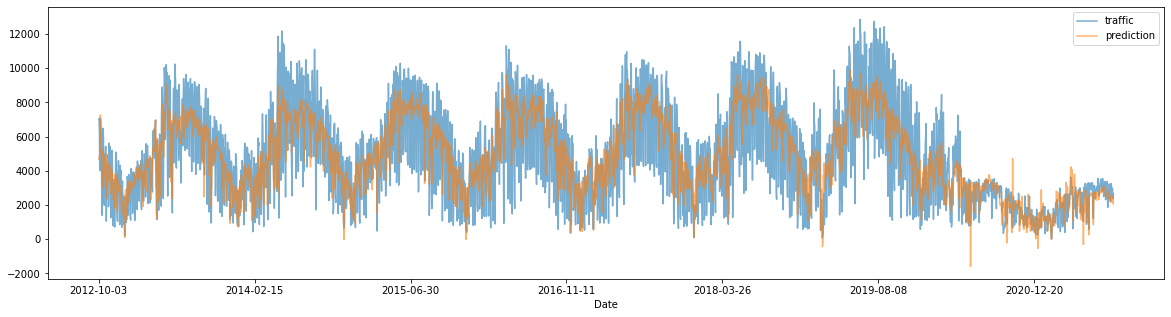

In [49]:
data[['traffic','prediction']].plot(figsize=(20,5),alpha=0.6)